In [1]:
import math

import torch
from transformers import AutoModelForImageClassification
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
model_name = "linkanjarad/mobilenet_v2_1.0_224-plant-disease-identification"

model = AutoModelForImageClassification.from_pretrained(model_name)
model.eval()

print("Model loaded")

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

Model loaded


In [3]:
labels = model.config.id2label

for i, label in labels.items():
    print(i, label)

0 Apple Scab
1 Apple with Black Rot
2 Cedar Apple Rust
3 Healthy Apple
4 Healthy Blueberry Plant
5 Cherry with Powdery Mildew
6 Healthy Cherry Plant
7 Corn (Maize) with Cercospora and Gray Leaf Spot
8 Corn (Maize) with Common Rust
9 Corn (Maize) with Northern Leaf Blight
10 Healthy Corn (Maize) Plant
11 Grape with Black Rot
12 Grape with Esca (Black Measles)
13 Grape with Isariopsis Leaf Spot
14 Healthy Grape Plant
15 Orange with Citrus Greening
16 Peach with Bacterial Spot
17 Healthy Peach Plant
18 Bell Pepper with Bacterial Spot
19 Healthy Bell Pepper Plant
20 Potato with Early Blight
21 Potato with Late Blight
22 Healthy Potato Plant
23 Healthy Raspberry Plant
24 Healthy Soybean Plant
25 Squash with Powdery Mildew
26 Strawberry with Leaf Scorch
27 Healthy Strawberry Plant
28 Tomato with Bacterial Spot
29 Tomato with Early Blight
30 Tomato with Late Blight
31 Tomato with Leaf Mold
32 Tomato with Septoria Leaf Spot
33 Tomato with Spider Mites or Two-spotted Spider Mite
34 Tomato with 

In [ ]:
from transformers import MobileNetV2ImageProcessor

# Use this model's own preprocessing config (resize shortest edge -> center
# crop -> normalize with mean/std 0.5).
processor = MobileNetV2ImageProcessor.from_pretrained(model_name)


def transform(image):
    return processor(image, return_tensors="pt")["pixel_values"][0]

In [ ]:
def calculate_entropy(probs):
    # handle batched probs (shape: [1, C]) as well as 1D tensors
    if probs.dim() > 1:
        probs = probs.squeeze(0)
    return -torch.sum(probs * torch.log(probs + 1e-10)).item()


def predict_plant_health(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0)

    with torch.no_grad():
        outputs = model(input_tensor)

    probs = torch.nn.functional.softmax(outputs.logits, dim=1)

    entropy = calculate_entropy(probs)

    # Top prediction
    confidence, predicted_class = torch.max(probs, dim=1)
    label = model.config.id2label[predicted_class.item()]

    # Top 3 predictions
    top3_probs, top3_indices = torch.topk(probs, 3)
    top3 = [
        (model.config.id2label[idx.item()], prob.item())
        for idx, prob in zip(top3_indices[0], top3_probs[0])
    ]

    return label, confidence.item(), top3, entropy

In [6]:
class GradCAM:
    """Grad-CAM: highlights which regions of the image most influenced the
    predicted class, using gradients flowing into the last conv layer."""

    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, target_class):
        self.model.zero_grad()
        score = self.model(input_tensor).logits[0, target_class]
        score.backward()

        gradients = self.gradients[0]      # (C, H, W)
        activations = self.activations[0]  # (C, H, W)
        weights = gradients.mean(dim=(1, 2))
        cam = torch.relu((weights[:, None, None] * activations).sum(dim=0))
        cam = cam / (cam.max() + 1e-8)
        return cam.detach().cpu()


# Last conv layer before global pooling — standard Grad-CAM target for MobileNetV2
gradcam = GradCAM(model, model.mobilenet_v2.conv_1x1.convolution)

In [7]:
import numpy as np
from matplotlib import cm


def compute_gradcam(image_path, target_class):
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0)
    input_tensor.requires_grad_(True)

    cam = gradcam.generate(input_tensor, target_class)  # low-res (7x7) map
    cam_np = cam.cpu().numpy()
    cam_img = Image.fromarray((cam_np * 255).astype("uint8"))
    cam_img = cam_img.resize(image.size, Image.BICUBIC)
    cam_resized = np.asarray(cam_img).astype("float32") / 255.0
    return image, cam_resized


def overlay_heatmap(image, cam, alpha=0.45):
    heatmap = (cm.jet(cam)[:, :, :3] * 255).astype("uint8")
    heatmap_img = Image.fromarray(heatmap).resize(image.size)
    return Image.blend(image, heatmap_img, alpha=alpha)


def lesion_area_fraction(cam, threshold=0.5):
    """Fraction of the image the model attended to strongly — a proxy for how
    much of the plant shows disease-relevant visual evidence. This is NOT a
    calibrated lesion segmentation, just Grad-CAM attention extent."""
    return float((cam > threshold).mean())

In [8]:
import os
import requests

GITHUB_REPO = "spMohanty/PlantVillage-Dataset"
GITHUB_BRANCH = "master"
REFERENCE_DIR = "reference_profiles"
REFERENCE_IMAGES_PER_CLASS = 15

# Folder names in the dataset this model was trained on, in the same order
# as model.config.id2label (index i here <-> label i) — lets us pull real
# reference examples for any of the 38 classes on demand.
PLANTVILLAGE_FOLDERS = [
    "Apple___Apple_scab", "Apple___Black_rot", "Apple___Cedar_apple_rust", "Apple___healthy",
    "Blueberry___healthy", "Cherry_(including_sour)___Powdery_mildew", "Cherry_(including_sour)___healthy",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot", "Corn_(maize)___Common_rust_",
    "Corn_(maize)___Northern_Leaf_Blight", "Corn_(maize)___healthy", "Grape___Black_rot",
    "Grape___Esca_(Black_Measles)", "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)", "Grape___healthy",
    "Orange___Haunglongbing_(Citrus_greening)", "Peach___Bacterial_spot", "Peach___healthy",
    "Pepper,_bell___Bacterial_spot", "Pepper,_bell___healthy", "Potato___Early_blight",
    "Potato___Late_blight", "Potato___healthy", "Raspberry___healthy", "Soybean___healthy",
    "Squash___Powdery_mildew", "Strawberry___Leaf_scorch", "Strawberry___healthy",
    "Tomato___Bacterial_spot", "Tomato___Early_blight", "Tomato___Late_blight", "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot", "Tomato___Spider_mites Two-spotted_spider_mite", "Tomato___Target_Spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus", "Tomato___Tomato_mosaic_virus", "Tomato___healthy",
]
LABEL_TO_FOLDER = {model.config.id2label[i]: PLANTVILLAGE_FOLDERS[i] for i in range(len(PLANTVILLAGE_FOLDERS))}
FOLDER_TO_LABEL = {v: k for k, v in LABEL_TO_FOLDER.items()}

# Crop keyword -> this model's "healthy" label for that crop, resolved through
# FOLDER_TO_LABEL so it always lines up with the id2label strings that
# get_class_profile()/fetch_reference_images() actually key on (crops without
# a healthy class in this model, e.g. Orange/Squash, are simply absent here)
HEALTHY_FOLDER_BY_CROP_KEYWORD = {
    "apple": "Apple___healthy",
    "blueberry": "Blueberry___healthy",
    "cherry": "Cherry_(including_sour)___healthy",
    "corn": "Corn_(maize)___healthy",
    "grape": "Grape___healthy",
    "peach": "Peach___healthy",
    "pepper": "Pepper,_bell___healthy",
    "potato": "Potato___healthy",
    "raspberry": "Raspberry___healthy",
    "soybean": "Soybean___healthy",
    "strawberry": "Strawberry___healthy",
    "tomato": "Tomato___healthy",
}
HEALTHY_LABEL_BY_CROP_KEYWORD = {k: FOLDER_TO_LABEL[v] for k, v in HEALTHY_FOLDER_BY_CROP_KEYWORD.items()}


def fetch_reference_images(label, n=REFERENCE_IMAGES_PER_CLASS):
    """Download n reference images for `label` from the model's source dataset.
    Cached to disk — only downloads on the first call for a given label."""
    folder = LABEL_TO_FOLDER[label]
    dest = os.path.join(REFERENCE_DIR, folder.replace(",", "").replace(" ", "_"))
    os.makedirs(dest, exist_ok=True)

    existing = [f for f in os.listdir(dest) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    if len(existing) >= n:
        return dest

    # Use the GitHub contents API to list files, and raw.githubusercontent to download
    api_url = f"https://api.github.com/repos/{GITHUB_REPO}/contents/color/{folder}"
    resp = requests.get(api_url, params={"ref": GITHUB_BRANCH})
    resp.raise_for_status()
    files = [f["name"] for f in resp.json() if f["name"].lower().endswith((".jpg", ".jpeg", ".png"))][:n]

    for fname in files:
        raw_url = f"https://raw.githubusercontent.com/{GITHUB_REPO}/{GITHUB_BRANCH}/color/{folder}/{fname}"
        img_resp = requests.get(raw_url)
        img_resp.raise_for_status()
        with open(os.path.join(dest, fname), "wb") as f:
            f.write(img_resp.content)

    return dest

In [9]:
embedding_store = {}


def _save_pooled_embedding(module, inp, out):
    embedding_store["embedding"] = out.detach().squeeze()


# Pooled feature vector right before the final classifier layer — a compact
# representation of "what the leaf looks like" the model uses to decide
model.mobilenet_v2.pooler.register_forward_hook(_save_pooled_embedding)


def get_embedding(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0)
    with torch.no_grad():
        model(input_tensor)
    return embedding_store["embedding"].clone()


K_NEIGHBORS = 5


def knn_distance(embedding, reference_embeddings, k=K_NEIGHBORS):
    """Mean cosine distance from `embedding` to its k nearest reference embeddings."""
    distances = 1 - torch.nn.functional.cosine_similarity(embedding.unsqueeze(0), reference_embeddings)
    k = min(k, reference_embeddings.shape[0])
    return torch.topk(distances, k, largest=False).values.mean().item()


class_profile_cache = {}


def get_class_profile(label):
    """Reference embeddings for `label`, plus a typical k-NN distance found by
    leave-one-out: how far each reference image sits from its own k nearest
    peers. k-NN instead of a single centroid means a reference image doesn't
    need to be near the class "average" to count as normal — just near
    *some* real example of that class, which holds up better for classes
    with varied appearance (angle, growth stage, lighting)."""
    if label in class_profile_cache:
        return class_profile_cache[label]

    crop_dir = fetch_reference_images(label)
    files = [f for f in os.listdir(crop_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    embeddings = torch.stack([get_embedding(os.path.join(crop_dir, f)) for f in files])

    normed = torch.nn.functional.normalize(embeddings, dim=1)
    pairwise = 1 - normed @ normed.T
    pairwise.fill_diagonal_(float("inf"))  # leave-one-out: never match yourself

    k = min(K_NEIGHBORS, len(files) - 1)
    loo_distances = torch.topk(pairwise, k, largest=False, dim=1).values.mean(dim=1)
    typical_distance = loo_distances.mean().item() + 2 * loo_distances.std().item()

    class_profile_cache[label] = {"embeddings": embeddings, "typical_distance": typical_distance}
    return class_profile_cache[label]

In [10]:
def pattern_match(image_path, label):
    """How closely this image matches real reference examples of its predicted
    class and of the healthy version of that crop, expressed as a ratio to
    each class's own typical k-NN spread (1.0x = typical, higher = more atypical).

    Uses k-nearest-neighbor distance rather than distance-to-centroid, so a
    class with varied appearance (angle, growth stage, lighting) isn't
    penalized just for not looking like the "average" example — it only
    needs to resemble some real reference image.

    Still a continuous ratio, not a hard flag: the reference photos (single
    leaf, plain background) look quite different from real field photos, so
    raw distances alone aren't reliable — normalizing by each class's own
    typical spread at least controls for that, though it doesn't fully
    remove it. Treat this as a "how well does it match anything we have on
    file" signal, not a calibrated drought detector.
    """
    embedding = get_embedding(image_path)

    predicted_profile = get_class_profile(label)
    ratio_to_predicted = knn_distance(embedding, predicted_profile["embeddings"]) / predicted_profile["typical_distance"]

    healthy_label = next((v for k, v in HEALTHY_LABEL_BY_CROP_KEYWORD.items() if k in label.lower()), None)
    if healthy_label and healthy_label != label:
        healthy_profile = get_class_profile(healthy_label)
        ratio_to_healthy = knn_distance(embedding, healthy_profile["embeddings"]) / healthy_profile["typical_distance"]
    else:
        ratio_to_healthy = ratio_to_predicted

    best_ratio = min(ratio_to_predicted, ratio_to_healthy)

    if best_ratio <= 1.2:
        note = "matches a known pattern"
    elif best_ratio <= 2.0:
        note = "somewhat atypical"
    else:
        note = "weak match to any known class — possible atypical/environmental stress"

    return {"ratio": best_ratio, "note": note}

In [11]:
# A uniform guess over all classes is the most "uncertain" the model can ever
# be, so use that (not a magic number) as the ceiling for the entropy term.
MAX_ENTROPY = math.log(len(model.config.id2label))


def compute_severity(label, confidence, top3, entropy, lesion_fraction=0.0, pattern_ratio=1.0):
    """Blend disease-label, visual (Grad-CAM + pattern-match), and model-uncertainty
    signals into a single 0-1 severity score.

    Low confidence / high entropy / a close top-2 call mean the *label* can't be
    trusted — they don't mean the *plant* is worse off. So when the top prediction
    is "healthy", only independent visual evidence (lesion area, pattern-match
    anomaly) is allowed to raise severity, and it's capped below "Critical": the
    model's own best guess is still healthy, so the most this should trigger is
    "worth a second look", never a disease alarm. Without this gate, a blurry
    photo of a genuinely healthy plant could score as "Critical" from uncertainty
    alone, which is exactly the false alarm a drought-stressed farmer can't afford
    to act on.
    """
    is_healthy = "healthy" in label.lower()
    top1, top2 = top3[0][1], top3[1][1]
    gap = top1 - top2

    uncertainty = (1 - confidence) * 0.5 + min(entropy / MAX_ENTROPY, 1.0) * 0.3 + (1 - gap) * 0.2

    # How far this image sits from any known reference pattern, as a 0-1 score
    # (ratio of 1.0x/typical contributes nothing; 3.0x+ maxes it out).
    anomaly = min(max(pattern_ratio - 1.0, 0.0) / 2.0, 1.0)
    visual_evidence = lesion_fraction * 0.5 + anomaly * 0.5

    if is_healthy:
        severity = min(visual_evidence, 0.65)
    else:
        severity = 0.35 + visual_evidence * 0.3 + uncertainty * 0.15
        if any(d in label.lower() for d in ["blight", "rot", "virus"]):
            severity += 0.2

    return min(severity, 1.0)


def severity_to_state(severity):
    if severity < 0.3:
        return "Healthy"
    elif severity < 0.7:
        return "Stressed"
    else:
        return "Critical"

In [12]:
from IPython.display import Markdown, display

# Short, safe, non-chemical first steps per disease family — deliberately
# generic (not dosing/product advice) since this tool can't know local
# regulations, crop stage, or severity in the field.
DISEASE_ADVICE = {
    "blight": "Blights spread fast in humid conditions. Remove affected leaves, avoid wetting the "
              "foliage when you water, and give plants room for airflow if you can.",
    "rot": "Rots often take hold in waterlogged soil. Check that water is draining away from the "
           "roots, and avoid overwatering even during dry spells — a little consistently beats a lot at once.",
    "virus": "Viruses can't be treated directly. Remove infected plants so they don't spread it, and "
              "control the insects (aphids, whiteflies) that usually carry them.",
    "rust": "Remove affected leaves and avoid wetting the foliage when watering.",
    "mildew": "Powdery mildew likes still, humid air. Improve airflow around the plant and water "
              "in the morning rather than evening.",
}
DEFAULT_DISEASE_ADVICE = ("Remove and dispose of the affected leaves so it doesn't spread, and avoid "
                           "getting water on the leaves when you irrigate.")


def advice_for(label):
    condition = label.lower()
    for keyword, tip in DISEASE_ADVICE.items():
        if keyword in condition:
            return tip
    return DEFAULT_DISEASE_ADVICE


def build_farmer_report(label, confidence, severity, state, lesion_fraction, pattern_ratio, pattern_note):
    """Plain-language summary for a farmer, in place of raw model internals
    (entropy, softmax scores, etc.) that aren't meaningful without ML background."""
    is_healthy = "healthy" in label.lower()
    lines = [f"### Result: {state}", ""]

    if state == "Healthy":
        lines.append(f"**{label}.** The leaf looks consistent with a healthy plant.")
    elif is_healthy:
        # Predicted healthy, but flagged Stressed on visual evidence alone
        lines.append(
            "**No specific disease detected, but the leaf looks unusual.** "
            f"About {lesion_fraction:.0%} of the image drew the model's attention, and the overall "
            f"pattern doesn't closely match healthy or diseased examples on file ({pattern_note}). "
            "This can be an early sign of water or heat stress, a nutrient issue, or something "
            "outside what this tool was trained to recognize — worth a closer look, especially if "
            "the plant has been short on water."
        )
    else:
        lines.append(f"**{label}.** {advice_for(label)}")
        if state == "Critical":
            lines.append(
                "\nThis looks serious enough to be worth talking to your local agricultural "
                "extension office, especially if you're seeing it on multiple plants."
            )

    if confidence < 0.5:
        lines.append(
            f"\n_Note: the model wasn't very confident in this reading ({confidence:.0%}). If "
            "possible, retake the photo in good light with the leaf filling the frame and try again._"
        )

    return "\n".join(lines)

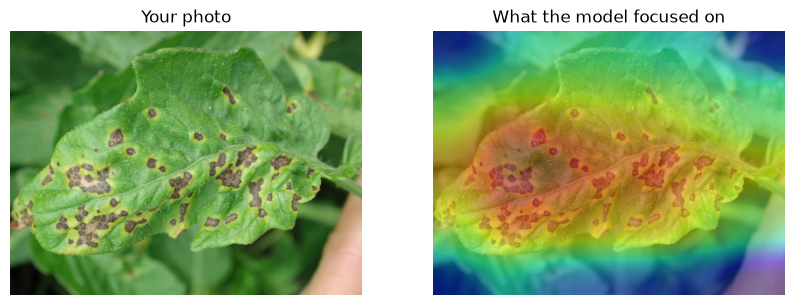

### Result: Stressed

**Tomato with Septoria Leaf Spot.** Remove and dispose of the affected leaves so it doesn't spread, and avoid getting water on the leaves when you irrigate.

[details] top prediction: Tomato with Septoria Leaf Spot (60% confidence) | severity score: 0.55 | pattern match: 1.6x typical spread


In [ ]:
image_path = "plant.jpg"  # change to your test image

label, confidence, top3, entropy = predict_plant_health(image_path)
target_class = model.config.label2id[label]

image, cam = compute_gradcam(image_path, target_class)
lesion_fraction = lesion_area_fraction(cam)
overlay = overlay_heatmap(image, cam)

match = pattern_match(image_path, label)

severity = compute_severity(label, confidence, top3, entropy, lesion_fraction, match["ratio"])
state = severity_to_state(severity)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image)
axes[0].set_title("Your photo")
axes[0].axis("off")
axes[1].imshow(overlay)
axes[1].set_title("What the model focused on")
axes[1].axis("off")
plt.show()

display(Markdown(build_farmer_report(
    label, confidence, severity, state, lesion_fraction, match["ratio"], match["note"],
)))

print(f"[details] top prediction: {label} ({confidence:.0%} confidence) | "
      f"severity score: {severity:.2f} | pattern match: {match['ratio']:.1f}x typical spread")